In [25]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets

# Cleaning data

### Cleaning X

In [26]:
X.drop(columns='fnlwgt', inplace=True)
X.head(5)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Cleaning y

In [3]:
#Conversion to series
y = y['income']

In [4]:
y.unique()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str

In [5]:
y = y.replace({'<=50K.':'<=50K', '>50K.':'>50K'})
y.unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [6]:
encoding_y = {'<=50K':0, 
              '>50K':1}
y = y.map(encoding_y)

### Handling NA

In [7]:
print(f'Number of NA: {X.isna().any(axis=1).sum()}')

Number of NA: 1221


In [8]:
idx_na = X.index[X.isna().any(axis=1)]
X.dropna(inplace=TrDue)
y.drop(index=idx_na, inplace=True)

# Training sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# EDA

In [21]:
y_train.value_counts(normalize=True)

income
0    0.757639
1    0.242361
Name: proportion, dtype: float64

In [62]:
X_train['capital-total'] = X_train['capital-gain'] - X_train['capital-loss']
data = X_train
data['income'] = y_train

In [97]:
sns.set_style("whitegrid")

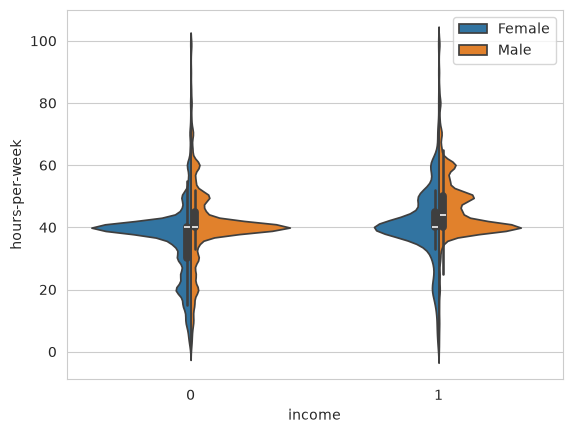

In [98]:
sns.violinplot(data=data, x = 'income', y = 'hours-per-week', hue = 'sex', split=True)
plt.legend(loc=0)

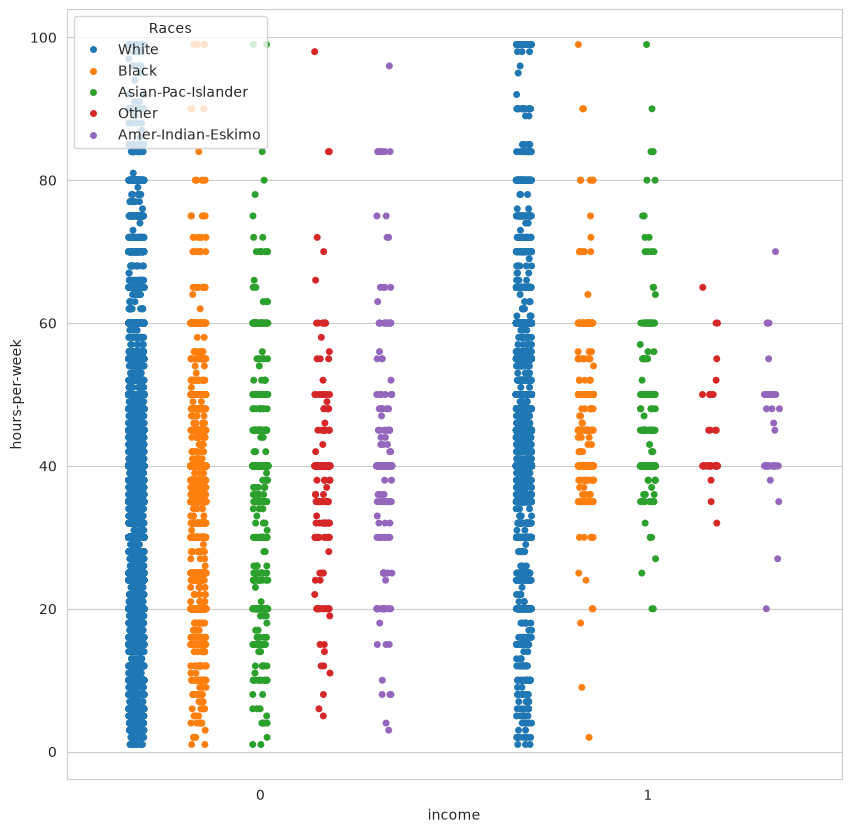

In [107]:
fig, ax = plt.subplots(figsize=(10,10))
sns.stripplot(ax=ax, data=data, x='income', y = 'hours-per-week', jitter=True, hue='race', dodge=True)
sns.move_legend(ax, loc='upper left', title='Races')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Husband'),
  Text(1, 0, 'Not-in-family'),
  Text(2, 0, 'Own-child'),
  Text(3, 0, 'Unmarried'),
  Text(4, 0, 'Wife'),
  Text(5, 0, 'Other-relative')])

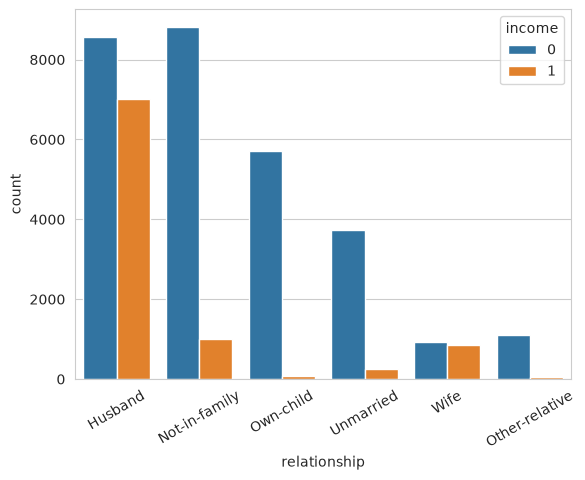

In [100]:
order = data['relationship'].value_counts().index

sns.countplot(data=data, x='relationship', hue='income', order=order)
plt.xticks(rotation=30)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Married-civ-spouse'),
  Text(1, 0, 'Never-married'),
  Text(2, 0, 'Divorced'),
  Text(3, 0, 'Separated'),
  Text(4, 0, 'Widowed'),
  Text(5, 0, 'Married-spouse-absent'),
  Text(6, 0, 'Married-AF-spouse')])

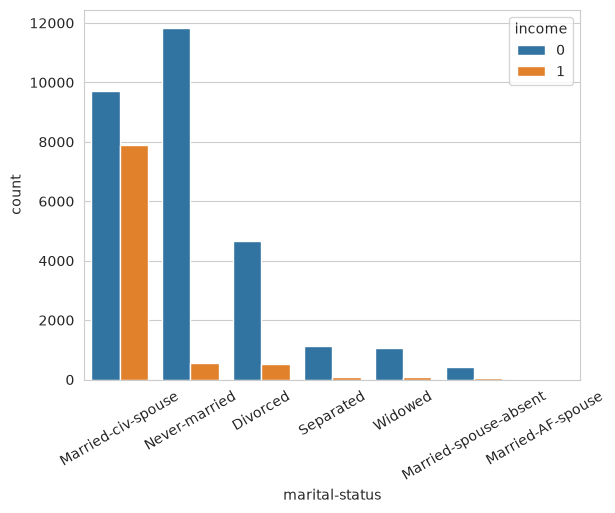

In [114]:
order = data['marital-status'].value_counts().index

sns.countplot(data=data, x='marital-status', hue='income', order=order)
plt.xticks(rotation=30)

<Axes: xlabel='marital-status', ylabel='relationship'>

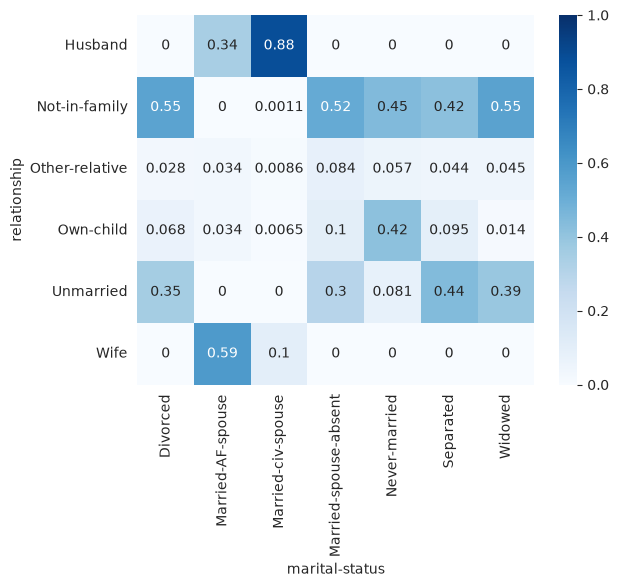

In [113]:
ct = pd.crosstab(data['relationship'], data['marital-status'], normalize='columns')
sns.heatmap(ct, annot=True, cmap='Blues', vmin=0, vmax=1)

In [ ]:
sns.histplotd 

In [73]:
data['native-country'].value_counts()

native-country
United-States                 34369
Mexico                          749
?                               473
Philippines                     239
Germany                         158
Canada                          142
Puerto-Rico                     139
El-Salvador                     123
India                           114
Cuba                            111
South                            98
China                            97
England                          96
Italy                            87
Jamaica                          84
Dominican-Republic               79
Japan                            70
Guatemala                        69
Vietnam                          67
Poland                           67
Columbia                         64
Portugal                         57
Haiti                            55
Taiwan                           53
Iran                             45
Ecuador                          40
Greece                           37
Peru         

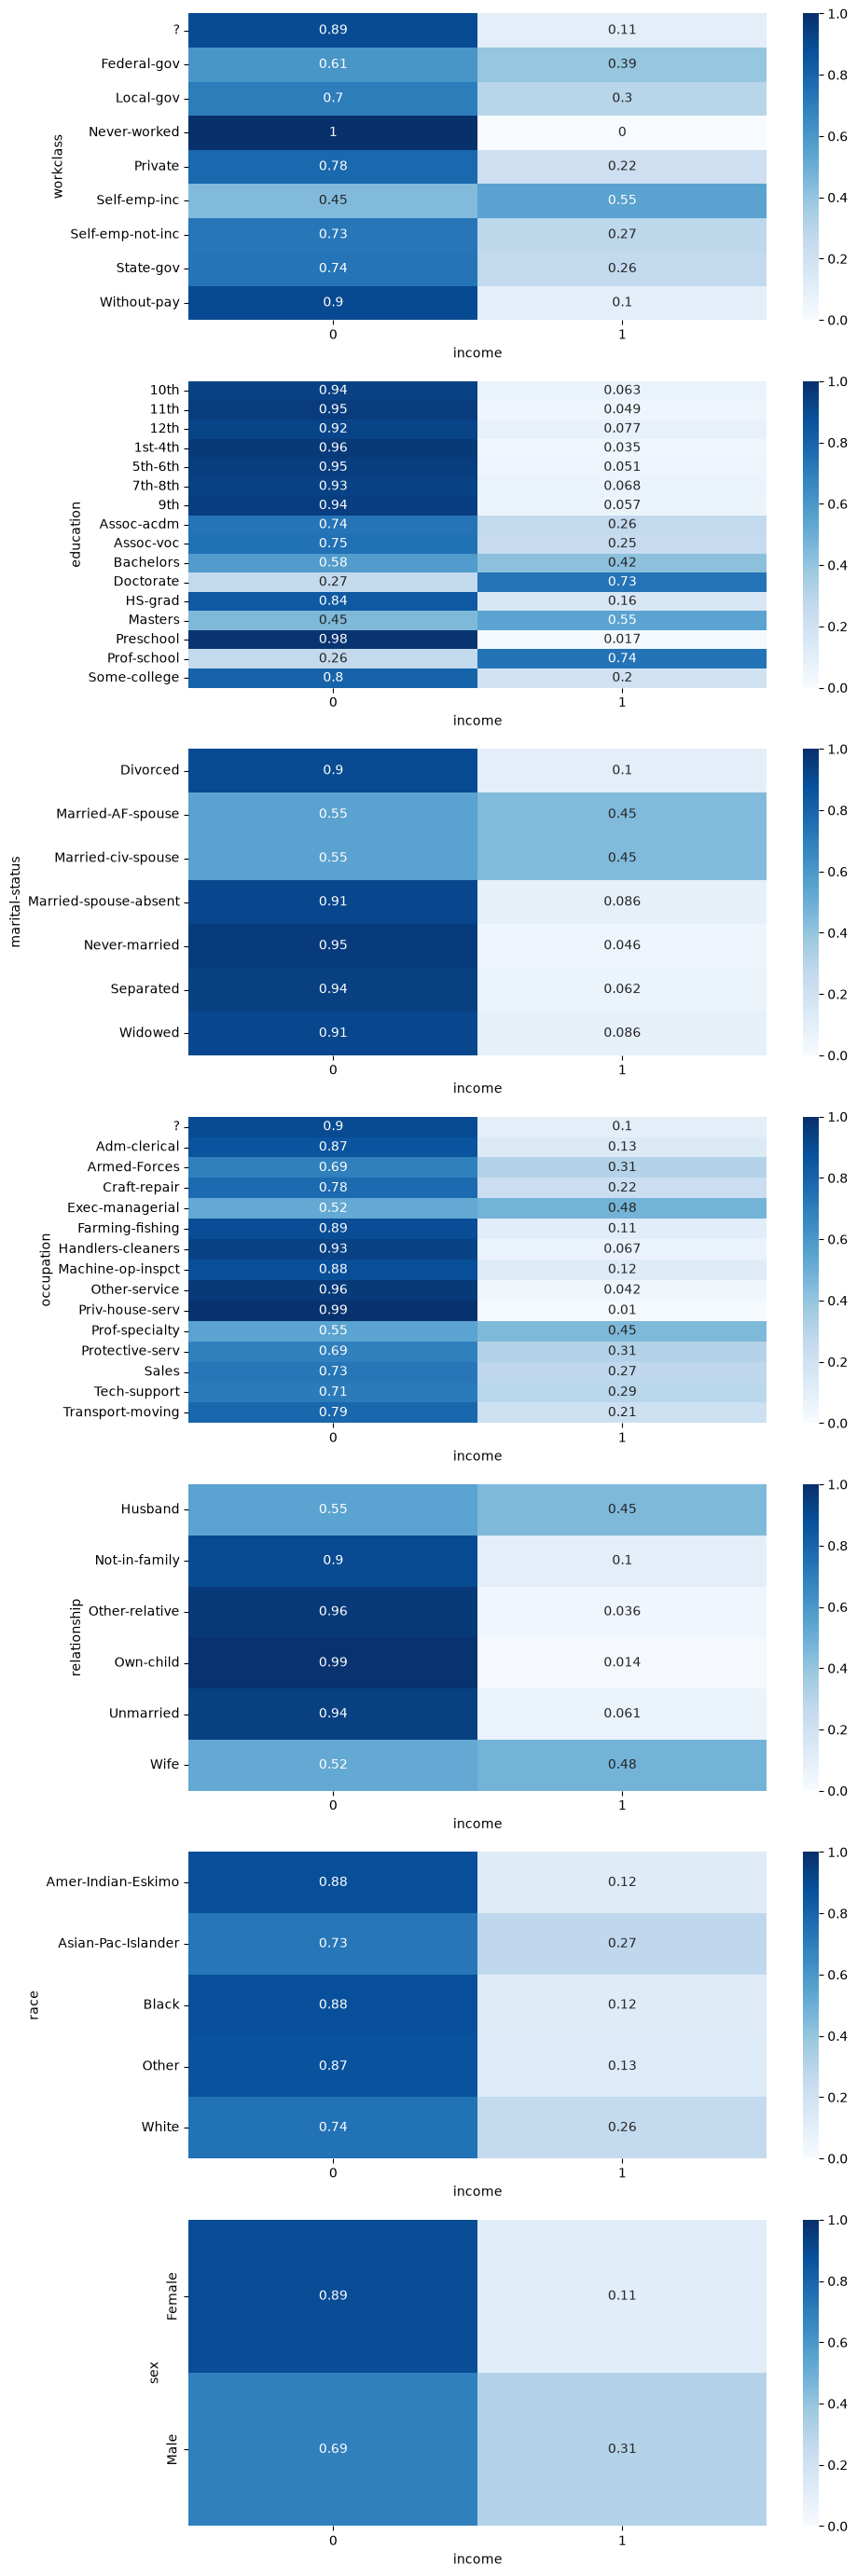

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex']

fig, ax = plt.subplots(len(cols), 1, figsize = (10, 35))
i = 0
for i, col in enumerate(cols):
    ct = pd.crosstab(X_train[col], y_train, normalize='index')
    sns.heatmap(ct, annot=True, cmap='Blues', vmin=0, vmax=1, ax=ax[i])
plt.show()

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin

class targetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, target_value):
        self.cols = cols
        self.target_value = target_value

    def fit(self, X, y):
        self.encodings_ = dict()
        for col in self.cols:
            encoding = (y == self.target_value).groupby(X[col]).mean()
            self.encodings_[col] = encoding
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.encodings_[col])
        return X
            

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex',
       'native-country']

pipe_tree = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('tree', DecisionTreeClassifier())
])

pipe_rfc = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('rfc', RandomForestClassifier())
])

pipe_xgb = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('xgbc', XGBClassifier())
])

In [13]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

def objective(trial):

    params = {
        'tree__max_depth':trial.suggest_int('max_depth', 10, 100),
        'tree__min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'tree__min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 10),
        'tree__max_leaf_nodes':trial.suggest_int('max_leaf_nodes', 20, 500),
        'tree__random_state':42}

    pipe_tree.set_params(**params)

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_tree,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST SCORE: {study.best_value}')
pipe_tree = pipe_tree.set_params(tree = DecisionTreeClassifier(**study.best_params))
pipe_tree.fit(X_train, y_train)    

[I 2026-07-18 18:44:50,518] A new study created in memory with name: no-name-8b27277e-e800-4364-ac9c-fb2de46302b8
[I 2026-07-18 18:44:50,872] Trial 0 finished with value: 0.8457689655694255 and parameters: {'max_depth': 19, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_leaf_nodes': 465}. Best is trial 0 with value: 0.8457689655694255.
[I 2026-07-18 18:44:51,183] Trial 1 finished with value: 0.8528504538567137 and parameters: {'max_depth': 57, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_leaf_nodes': 96}. Best is trial 1 with value: 0.8528504538567137.
[I 2026-07-18 18:44:51,502] Trial 2 finished with value: 0.8532228998290814 and parameters: {'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_leaf_nodes': 151}. Best is trial 2 with value: 0.8532228998290814.
[I 2026-07-18 18:44:51,833] Trial 3 finished with value: 0.8494434265950227 and parameters: {'max_depth': 35, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_leaf_nodes': 294}. Best is trial 2

BEST SCORE: 0.8538315504466022


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",44


In [14]:
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    params = {
        'rfc__n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'rfc__max_depth' : trial.suggest_int('max_depth', 5, 30),
        'rfc__min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'rfc__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
    }
    
    pipe_rfc.set_params(**params)
    
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_rfc,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=4)

print(f'BEST SCORE: {study.best_value}')
pipe_rfc = pipe_rfc.set_params(rfc = RandomForestClassifier(**study.best_params))
pipe_rfc.fit(X_train, y_train)

[I 2026-07-18 18:45:22,280] A new study created in memory with name: no-name-c1838e34-31df-46d3-ac46-5dc901020339
[I 2026-07-18 18:45:26,850] Trial 0 finished with value: 0.8583403178298955 and parameters: {'n_estimators': 89, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8583403178298955.
[I 2026-07-18 18:45:31,301] Trial 1 finished with value: 0.8572191485969026 and parameters: {'n_estimators': 95, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8583403178298955.
[I 2026-07-18 18:45:49,671] Trial 2 finished with value: 0.8567844226466454 and parameters: {'n_estimators': 436, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8583403178298955.
[I 2026-07-18 18:45:54,131] Trial 3 finished with value: 0.856251660034692 and parameters: {'n_estimators': 75, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.

BEST SCORE: 0.8583403178298955


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('rfc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",89


In [15]:
def objective(trial):
    params = {
        'xgbc__n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'xgbc__max_depth' : trial.suggest_int('max_depth', 5, 12),
        'xgbc__learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'xgbc__gamma' : trial.suggest_float('gamma', 0.01, 0.4),
        'xgbc__reg_lambda' : trial.suggest_float('reg_lambda', 1, 10, log=True),
        'xgbc__reg_alpha' : trial.suggest_float('reg_alpha', 0.001, 10, log=True),
        'xgbc__subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'xgbc__colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1)}
    
    pipe_xgb.set_params(**params)
        
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_xgb,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f'BEST SCORE: {study.best_value}')
pipe_xgb = pipe_xgb.set_params(xgbc = XGBClassifier(**study.best_params))
pipe_xgb.fit(X_train, y_train)

[I 2026-07-18 18:45:55,791] A new study created in memory with name: no-name-4521e41c-faaa-45d1-9780-fbca8f6e617f
[I 2026-07-18 18:45:57,607] Trial 0 finished with value: 0.8592139945161981 and parameters: {'n_estimators': 170, 'max_depth': 11, 'learning_rate': 0.1949861746554257, 'gamma': 0.08289584592627751, 'reg_lambda': 4.1376919140664885, 'reg_alpha': 0.020849082239149223, 'subsample': 0.8983368760026064, 'colsample_bytree': 0.6726821801295859}. Best is trial 0 with value: 0.8592139945161981.
[I 2026-07-18 18:45:58,945] Trial 1 finished with value: 0.8661240552066181 and parameters: {'n_estimators': 265, 'max_depth': 5, 'learning_rate': 0.06994747436016696, 'gamma': 0.28114848350403443, 'reg_lambda': 8.172283558543718, 'reg_alpha': 2.986346515166054, 'subsample': 0.8077999735367614, 'colsample_bytree': 0.7734846997087115}. Best is trial 1 with value: 0.8661240552066181.
[I 2026-07-18 18:46:01,240] Trial 2 finished with value: 0.8627750587377744 and parameters: {'n_estimators': 448

BEST SCORE: 0.8661240552066181


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('xgbc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None


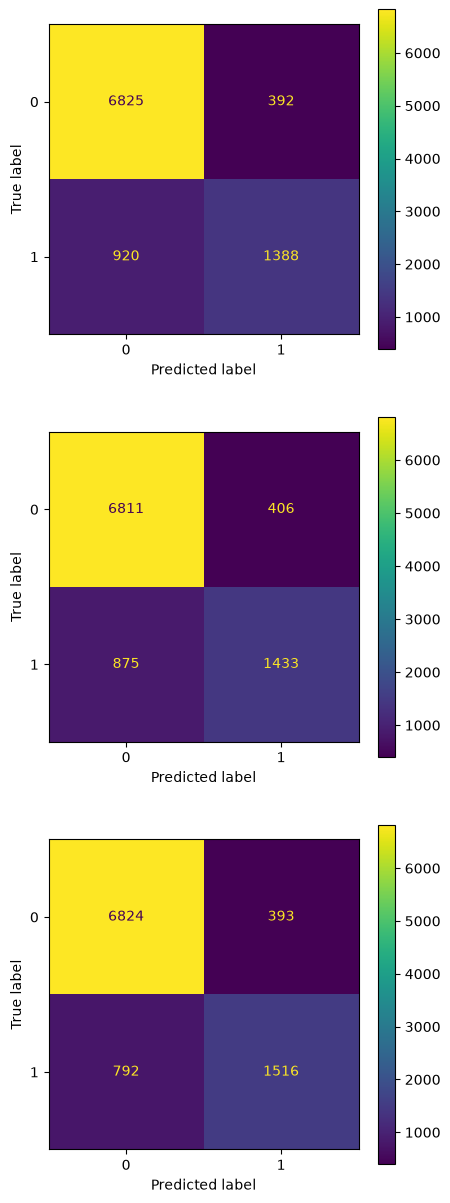

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(3, 1, figsize=(5, 15))

ConfusionMatrixDisplay.from_estimator(pipe_tree, X_test, y_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(pipe_rfc, X_test, y_test, ax=ax[1])
ConfusionMatrixDisplay.from_estimator(pipe_xgb, X_test, y_test, ax=ax[2])

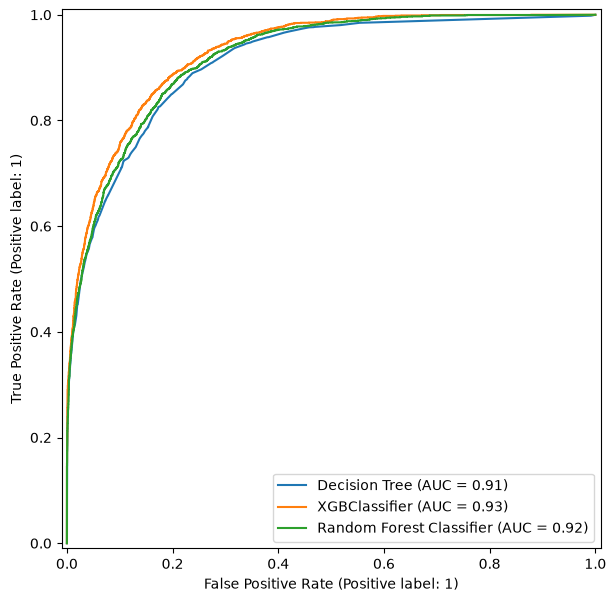

In [17]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize = (7,7))

RocCurveDisplay.from_estimator(pipe_tree, X_test, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(pipe_xgb, X_test, y_test, ax=ax, name='XGBClassifier')
RocCurveDisplay.from_estimator(pipe_rfc, X_test, y_test, ax=ax, name='Random Forest Classifier')
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score

names = {pipe_tree: 'Decision Tree Classifier',
             pipe_rfc: 'Random Forest Classifier', 
             pipe_xgb: 'XGBoost Classifier'}

for model in (pipe_tree, pipe_rfc, pipe_xgb):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_pred, y_test)
    pre = precision_score(y_pred, y_test)
    print(names[model])
    print(f'Accuracy: {acc},\n Precision {pre}\n')

Decision Tree Classifier
Accuracy: 0.862257217847769,
 Precision 0.6013864818024264

Random Forest Classifier
Accuracy: 0.8655118110236221,
 Precision 0.6208838821490468

XGBoost Classifier
Accuracy: 0.8755905511811024,
 Precision 0.6568457538994801

